# Human Activity Recognition

https://www.kaggle.com/datasets/die9origephit/human-activity-recognition/data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/Elogroup/CNH data literacy/Adv/M4/time_series_data_human_activities.csv")

df.head()

,user,activity,timestamp,x-axis,y-axis,z-axis
0,1,Walking,4991922345000,0.69,10.80,-2.03
1,1,Walking,4991972333000,6.85,7.44,-0.50
2,1,Walking,4992022351000,0.93,5.63,-0.50
3,1,Walking,4992072339000,-2.11,5.01,-0.69
4,1,Walking,4992122358000,-4.59,4.29,-1.95


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1073623 entries, 0 to 1073622
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   user       1073623 non-null  int64  
 1   activity   1073623 non-null  object 
 2   timestamp  1073623 non-null  int64  
 3   x-axis     1073623 non-null  float64
 4   y-axis     1073623 non-null  float64
 5   z-axis     1073623 non-null  float64
dtypes: float64(3), int64(2), object(1)
memory usage: 49.1+ MB


## Choose one user

We will work with only one user first.
This makes the visualization easier and avoids mixing different people in the same plot.

In [3]:
chosen_user = 1

user_df = df[df["user"] == chosen_user].copy()
user_df.head()

,user,activity,timestamp,x-axis,y-axis,z-axis
0,1,Walking,4991922345000,0.69,10.80,-2.03
1,1,Walking,4991972333000,6.85,7.44,-0.50
2,1,Walking,4992022351000,0.93,5.63,-0.50
3,1,Walking,4992072339000,-2.11,5.01,-0.69
4,1,Walking,4992122358000,-4.59,4.29,-1.95


In [4]:
user_df["activity"].unique()

array(['Walking', 'Jogging', 'Upstairs', 'Downstairs'], dtype=object)

## Convert timestamp to seconds

The timestamp is stored in nanoseconds, but it should not be interpreted as a real calendar date.

Instead, it behaves like elapsed time from the sensor recording.  
So we subtract the first timestamp of this user and divide by 1e9.

This makes the recording start at 0 seconds.

In [5]:
user_df = user_df.sort_values("timestamp")

user_df["time_seconds"] = (
    user_df["timestamp"] - user_df["timestamp"].min()
) / 1e9

user_df.head()

,user,activity,timestamp,x-axis,y-axis,z-axis,time_seconds
0,1,Walking,4991922345000,0.69,10.80,-2.03,0.000000
1,1,Walking,4991972333000,6.85,7.44,-0.50,0.049988
2,1,Walking,4992022351000,0.93,5.63,-0.50,0.100006
3,1,Walking,4992072339000,-2.11,5.01,-0.69,0.149994
4,1,Walking,4992122358000,-4.59,4.29,-1.95,0.200013


## Check time differences

Before plotting the signals, we check the time difference between consecutive records.

This helps us understand the sampling rate and whether there are gaps in the recording.

In [6]:
user_df["previous_time"] = user_df["time_seconds"].shift()
user_df["time_diff"] = user_df["time_seconds"] - user_df["previous_time"]

user_df[["previous_time", "time_seconds", "time_diff", "activity"]].head()

,previous_time,time_seconds,time_diff,activity
0,NaN,0.000000,NaN,Walking
1,0.000000,0.049988,0.049988,Walking
2,0.049988,0.100006,0.050018,Walking
3,0.100006,0.149994,0.049988,Walking
4,0.149994,0.200013,0.050019,Walking


In [7]:
normal_interval = user_df["time_diff"].median()
normal_interval

0.049988000000041666

Now we plot the activity labels over time.

This plot is important because it shows that activities alternate.  
The same activity can appear in different moments instead of being one continuous block.

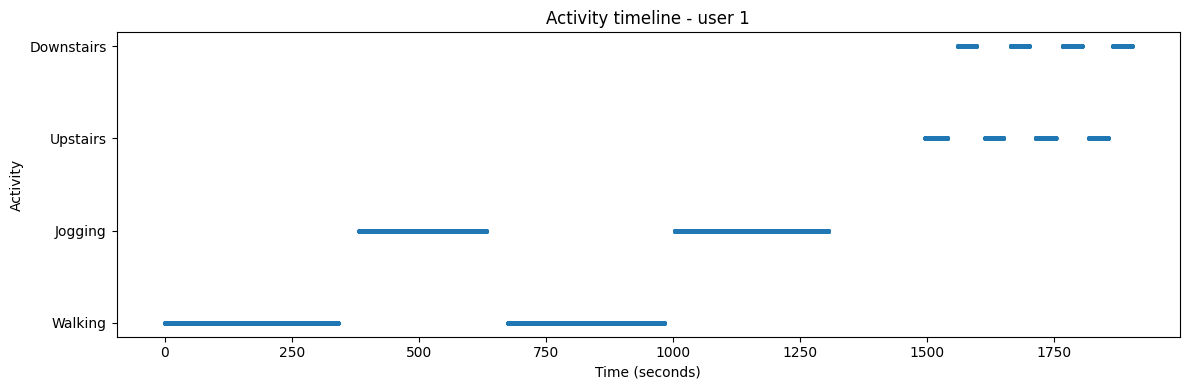

In [8]:
plt.figure(figsize=(12, 4))

plt.scatter(
    user_df["time_seconds"],
    user_df["activity"],
    s=5
)

plt.title(f"Activity timeline - user {chosen_user}")
plt.xlabel("Time (seconds)")
plt.ylabel("Activity")
plt.tight_layout()
plt.show()

A gap happens when the difference between two consecutive timestamps is much larger than the normal sampling interval.

Instead of automatically assuming every slightly larger interval is a gap, we first inspect the biggest time differences.

In [9]:
gap_limit = 1

user_df["is_gap"] = user_df["time_diff"] > gap_limit
user_df["is_gap"].value_counts()

,count
is_gap,
False,29966
True,12


The shaded regions show time intervals where there is no recorded activity.

These intervals should not be counted as part of the previous activity or the next activity.

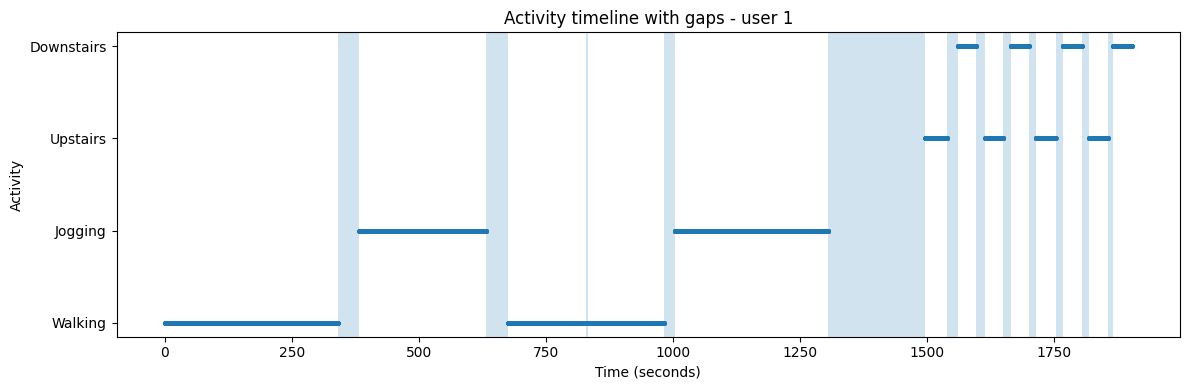

In [10]:
plt.figure(figsize=(12, 4))

plt.scatter(
    user_df["time_seconds"],
    user_df["activity"],
    s=5
)

for _, row in user_df[user_df["is_gap"]].iterrows():
    plt.axvspan(
        row["previous_time"],
        row["time_seconds"],
        alpha=0.2
    )

plt.title(f"Activity timeline with gaps - user {chosen_user}")
plt.xlabel("Time (seconds)")
plt.ylabel("Activity")
plt.tight_layout()
plt.show()

Because activities alternate, calculating duration using only max time minus min time for each activity would be wrong.

Instead, we create continuous blocks.

A new block starts when:

- the activity changes
- or there is a real time gap

In [11]:
user_df["activity_changed"] = user_df["activity"] != user_df["activity"].shift()

user_df["new_block"] = user_df["activity_changed"] | user_df["is_gap"]

user_df["activity_block"] = user_df["new_block"].cumsum()

user_df[["time_seconds", "activity", "time_diff", "is_gap", "activity_block"]].head(10)

,time_seconds,activity,time_diff,is_gap,activity_block
0,0.000000,Walking,NaN,False,1
1,0.049988,Walking,0.049988,False,1
2,0.100006,Walking,0.050018,False,1
3,0.149994,Walking,0.049988,False,1
4,0.200013,Walking,0.050019,False,1
5,0.250031,Walking,0.050018,False,1
6,0.299988,Walking,0.049957,False,1
7,0.349976,Walking,0.049988,False,1
8,0.399994,Walking,0.050018,False,1
9,0.449982,Walking,0.049988,False,1


## Compare with number of records

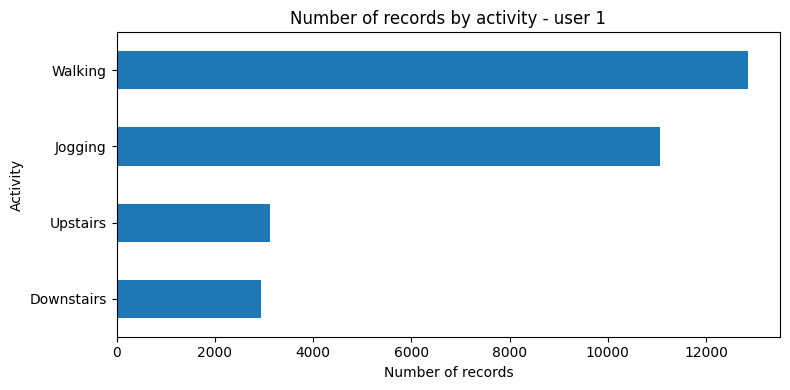

In [12]:
user_df["activity"].value_counts().sort_values().plot(
    kind="barh",
    figsize=(8, 4)
)

plt.title(f"Number of records by activity - user {chosen_user}")
plt.xlabel("Number of records")
plt.ylabel("Activity")
plt.tight_layout()
plt.show()

## Plot acceleration signals in a short window

Plotting the full accelerometer signal is too confusing because there are many records.

So we start with a short time window.

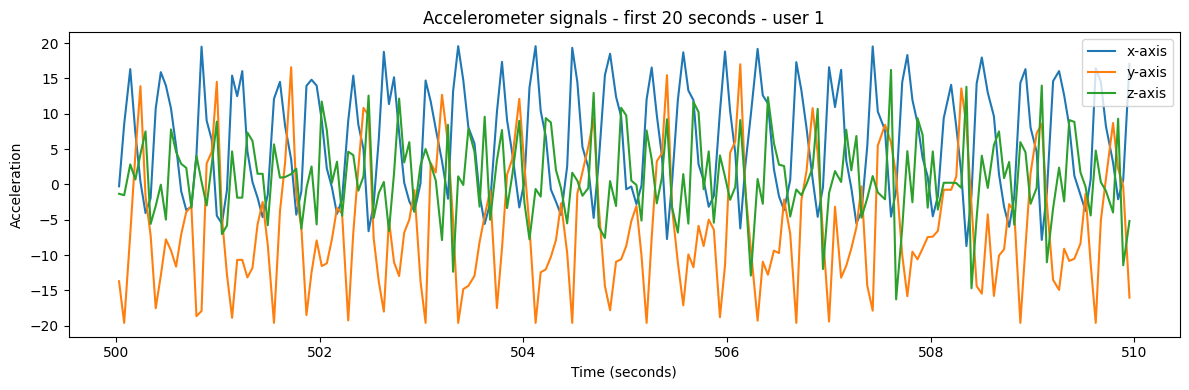

In [13]:
# jogging
sample_df = user_df[(user_df["time_seconds"] >= 500) & (user_df["time_seconds"] <= 510)]

plt.figure(figsize=(12, 4))

plt.plot(sample_df["time_seconds"], sample_df["x-axis"], label="x-axis")
plt.plot(sample_df["time_seconds"], sample_df["y-axis"], label="y-axis")
plt.plot(sample_df["time_seconds"], sample_df["z-axis"], label="z-axis")

plt.title(f"Accelerometer signals - first 20 seconds - user {chosen_user}")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration")
plt.legend()
plt.tight_layout()
plt.show()

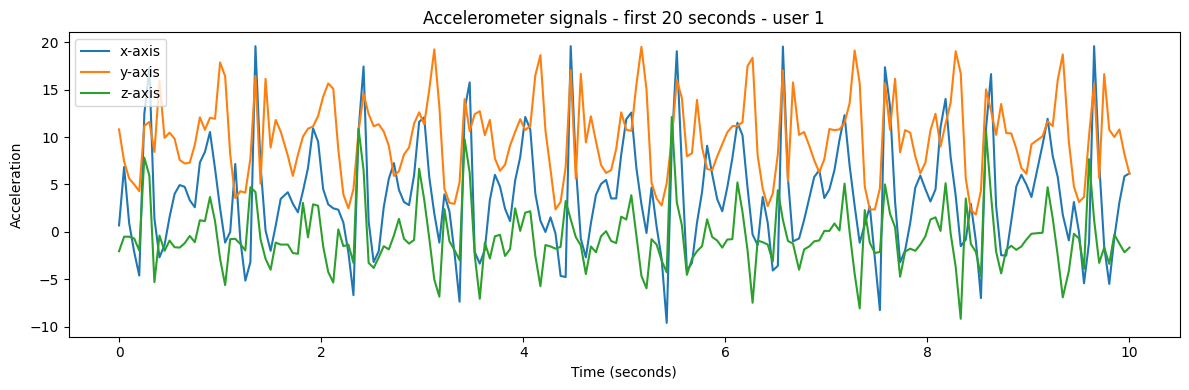

In [14]:
# jogging
sample_df = user_df[(user_df["time_seconds"] >= 0) & (user_df["time_seconds"] <= 10)]

plt.figure(figsize=(12, 4))

plt.plot(sample_df["time_seconds"], sample_df["x-axis"], label="x-axis")
plt.plot(sample_df["time_seconds"], sample_df["y-axis"], label="y-axis")
plt.plot(sample_df["time_seconds"], sample_df["z-axis"], label="z-axis")

plt.title(f"Accelerometer signals - first 20 seconds - user {chosen_user}")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration")
plt.legend()
plt.tight_layout()
plt.show()

## Compare x, y and z by activity

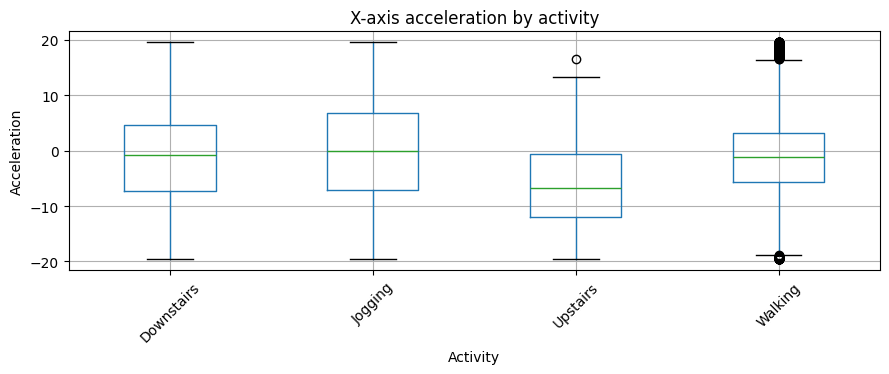

In [15]:
user_df.boxplot(
    column="x-axis",
    by="activity",
    figsize=(9, 4),
    rot=45
)

plt.title("X-axis acceleration by activity")
plt.suptitle("")
plt.xlabel("Activity")
plt.ylabel("Acceleration")
plt.tight_layout()
plt.show()

## Creating the Machine Learning Dataset

The original dataset is a time series. Each row represents one accelerometer reading at a specific moment in time.

However, most machine learning models do not work directly with continuous time series in this format. They expect a table where each row is one example and each column is one feature.

To solve this, we transform the accelerometer signal into windows.

Each window contains a fixed number of consecutive sensor readings. In this case, we use:

- `window_size = 40`
- `step_size = 20`

If the sensor records around 20 readings per second, then 40 readings represent approximately 2 seconds of movement.

The `step_size` controls how much the window moves forward each time. Since the step size is 20, the windows overlap 50%.

For example:

- Window 1 uses rows 0 to 39
- Window 2 uses rows 20 to 59
- Window 3 uses rows 40 to 79

This overlap helps create more training examples and captures movement patterns more smoothly.

The windows are created separately inside each continuous activity block. This is important because we do not want one window to mix different activities, such as half Walking and half Sitting.

For each window, we calculate simple statistical features from the accelerometer axes:

- mean of the x-axis
- standard deviation of the x-axis
- mean of the y-axis
- standard deviation of the y-axis
- mean of the z-axis
- standard deviation of the z-axis

The mean gives the average acceleration in that short time interval.

The standard deviation shows how much the acceleration varies during that interval. This is useful because activities with more movement, such as Walking, usually have higher variation than activities like Sitting or Standing.

Each window becomes one row in the new machine learning dataset.

The activity of that window becomes the target variable.

In [16]:
window_size = 40
step_size = 20

rows = []

for block_id in user_df["activity_block"].unique():

    block_data = user_df[user_df["activity_block"] == block_id].copy()
    block_data = block_data.sort_values("time_seconds")

    activity = block_data["activity"].iloc[0]

    if len(block_data) < window_size:
        continue

    for start in range(0, len(block_data) - window_size, step_size):

        window = block_data.iloc[start:start + window_size]

        row = {
            "activity": activity,

            "x_mean": window["x-axis"].mean(),
            "x_std": window["x-axis"].std(),

            "y_mean": window["y-axis"].mean(),
            "y_std": window["y-axis"].std(),

            "z_mean": window["z-axis"].mean(),
            "z_std": window["z-axis"].std()
        }

        rows.append(row)

In [17]:
ml_df = pd.DataFrame(rows)

ml_df.head()

,activity,x_mean,x_std,y_mean,y_std,z_mean,z_std
0,Walking,3.80075,5.482239,9.64950,3.626163,-0.27850,2.827287
1,Walking,3.52225,5.487892,9.87775,4.027795,-0.48975,3.405177
2,Walking,3.48625,5.551209,9.91900,3.956199,-0.50250,3.983298
3,Walking,3.53825,5.766730,9.93400,4.365711,-0.72675,3.206902
4,Walking,3.85725,6.169201,9.89050,4.528499,-0.71175,3.138659


The target variable is the activity.

The input variables are the features extracted from each window.

In [18]:
X = ml_df.drop(columns="activity")
y = ml_df["activity"]

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Create Classification Model and Evaluate

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)

print(classification_report(y_test, log_preds))

              precision    recall  f1-score   support

  Downstairs       0.90      0.68      0.78        28
     Jogging       0.96      0.99      0.97       110
    Upstairs       0.85      0.77      0.81        30
     Walking       0.96      1.00      0.98       128

    accuracy                           0.94       296
   macro avg       0.92      0.86      0.88       296
weighted avg       0.94      0.94      0.94       296



In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

  Downstairs       1.00      0.79      0.88        28
     Jogging       0.97      1.00      0.99       110
    Upstairs       0.93      0.83      0.88        30
     Walking       0.96      1.00      0.98       128

    accuracy                           0.96       296
   macro avg       0.96      0.90      0.93       296
weighted avg       0.96      0.96      0.96       296



_**Disclaimer:** This material was partially based on previous classes and research given by Poliana N. Ferreira_